# DATATHON 2026 — Part 1


## 1. Import và Setup

In [40]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

SEED = 42
np.random.seed(SEED)

# =========================
# CONFIG: chỉnh DATA_DIR nếu cần
# =========================
CANDIDATE_DIRS = [
    Path('/content/data'),
    Path('/mnt/data'),
    Path('data'),
    Path('.')]

DATA_DIR = None
for p in CANDIDATE_DIRS:
    if p.exists() and (p / 'orders.csv').exists():
        DATA_DIR = p
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        'Không tìm thấy thư mục dữ liệu. Hãy upload các file CSV vào /content/data hoặc chỉnh biến DATA_DIR.'
    )

print(f'DATA_DIR = {DATA_DIR.resolve()}')


DATA_DIR = /content


## 2. Load dữ liệu

In [41]:
def read_csv(name, parse_dates=None):
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f'Thiếu file: {path}')
    return pd.read_csv(path, parse_dates=parse_dates, low_memory=False)

orders = read_csv('orders.csv', parse_dates=['order_date'])
products = read_csv('products.csv')
returns = read_csv('returns.csv', parse_dates=['return_date'])
web_traffic = read_csv('web_traffic.csv', parse_dates=['date'])
order_items = read_csv('order_items.csv')
customers = read_csv('customers.csv', parse_dates=['signup_date'])
geography = read_csv('geography.csv')
payments = read_csv('payments.csv')

raw_tables = {
    'orders': orders,
    'products': products,
    'returns': returns,
    'web_traffic': web_traffic,
    'order_items': order_items,
    'customers': customers,
    'geography': geography,
    'payments': payments,
}

summary = pd.DataFrame({
    'table': list(raw_tables.keys()),
    'n_rows': [len(df) for df in raw_tables.values()],
    'n_cols': [df.shape[1] for df in raw_tables.values()],
    'missing_cells': [int(df.isna().sum().sum()) for df in raw_tables.values()],
})
summary


,table,n_rows,n_cols,missing_cells
0,orders,646945,8,0
1,products,2412,8,0
2,returns,39939,7,0
3,web_traffic,3652,7,0
4,order_items,714669,7,1152816
5,customers,121930,7,0
6,geography,39948,4,0
7,payments,646945,4,0


## 3. Helper functions


In [42]:
def show_ranked_series(s, title='', top=None):
    if top is not None:
        s = s.head(top)
    display(s.to_frame('value'))
    ax = s.sort_values().plot(kind='barh', figsize=(8, max(3, 0.45 * len(s))))
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

# 4. Tính toán từng câu hỏi


## Q1. Median inter-order gap



In [43]:
oo = orders.sort_values(['customer_id', 'order_date']).copy()
oo['inter_order_gap'] = oo.groupby('customer_id')['order_date'].diff().dt.days
q1_value = oo['inter_order_gap'].dropna().median()

print(f'Q1 median inter-order gap = {q1_value:.0f} ngày')

Q1 median inter-order gap = 144 ngày


## Q2. Segment có gross margin trung bình cao nhất



Q2 segment cao nhất = Standard


,value
segment,
Standard,0.3134
Premium,0.2854
All-weather,0.2842
Activewear,0.2656
Performance,0.2636
Balanced,0.2580
Trendy,0.2408
Everyday,0.2363


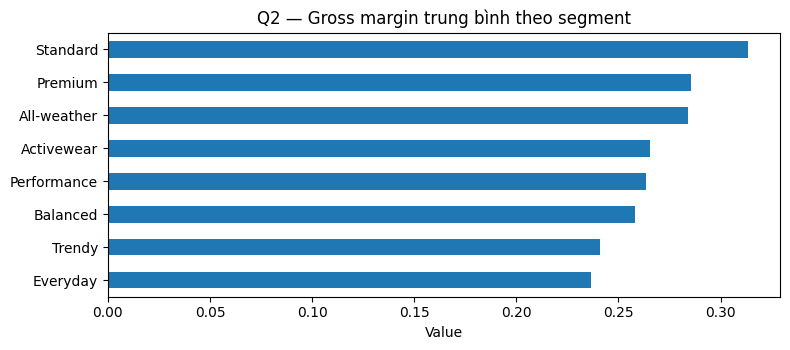

In [44]:
products_q2 = products.copy()
products_q2['gross_margin_rate'] = (products_q2['price'] - products_q2['cogs']) / products_q2['price']
q2_series = products_q2.groupby('segment')['gross_margin_rate'].mean().sort_values(ascending=False)
q2_answer_value = q2_series.index[0]

print(f'Q2 segment cao nhất = {q2_answer_value}')
show_ranked_series(q2_series, 'Q2 — Gross margin trung bình theo segment')

## Q3. Lý do trả hàng phổ biến nhất với sản phẩm Streetwear


Q3 return reason phổ biến nhất = wrong_size


,value
return_reason,
wrong_size,7626
defective,4330
not_as_described,3854
changed_mind,3830
late_delivery,2159


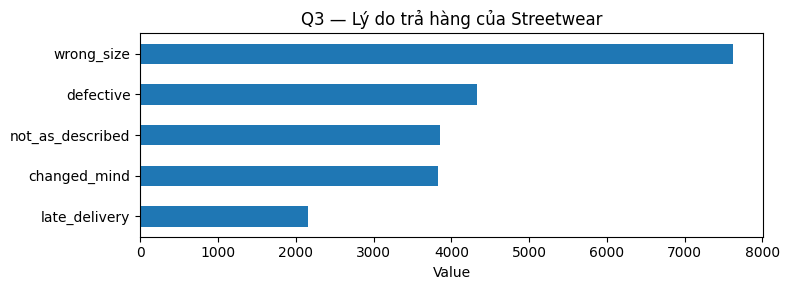

In [45]:
r_prod = returns.merge(products[['product_id', 'category']], on='product_id', how='left')
streetwear_returns = r_prod[r_prod['category'].eq('Streetwear')]
q3_series = streetwear_returns['return_reason'].value_counts()
q3_answer_value = q3_series.index[0]

print(f'Q3 return reason phổ biến nhất = {q3_answer_value}')
show_ranked_series(q3_series, 'Q3 — Lý do trả hàng của Streetwear')

## Q4. Traffic source có bounce rate trung bình thấp nhất



Q4 traffic source thấp nhất = email_campaign


,value
traffic_source,
direct,0.0045
organic_search,0.0045
referral,0.0045
paid_search,0.0045
social_media,0.0045
email_campaign,0.0045


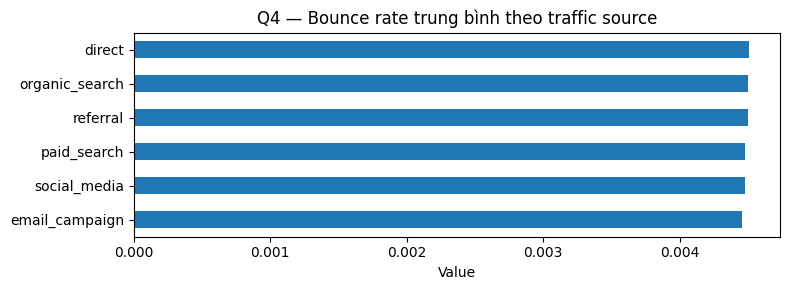

In [46]:
q4_series = web_traffic.groupby('traffic_source')['bounce_rate'].mean().sort_values()
q4_answer_value = q4_series.index[0]

print(f'Q4 traffic source thấp nhất = {q4_answer_value}')
show_ranked_series(q4_series.sort_values(ascending=False), 'Q4 — Bounce rate trung bình theo traffic source')

## Q5. Tỷ lệ dòng order_items có promo_id khác null


In [47]:
q5_value = order_items['promo_id'].notna().mean() * 100

print(f'Q5 tỷ lệ dòng có promo_id = {q5_value:.2f}%')

Q5 tỷ lệ dòng có promo_id = 38.66%


## Q6. Age group có số đơn trung bình trên mỗi khách hàng cao nhất


Q6 age group cao nhất = 55+


,value
age_group,
55+,5.4069
45-54,5.3572
35-44,5.3373
25-34,5.2452
18-24,5.2267


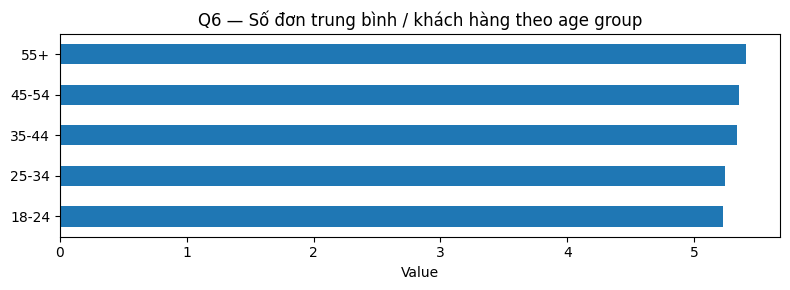

In [48]:
orders_per_customer = orders.groupby('customer_id').size().rename('n_orders')
customer_age = customers[customers['age_group'].notna()].copy()
customer_orders = customer_age.merge(
    orders_per_customer,
    left_on='customer_id',
    right_index=True,
    how='left'
).fillna({'n_orders': 0})

q6_series = customer_orders.groupby('age_group')['n_orders'].mean().sort_values(ascending=False)
q6_answer_value = q6_series.index[0]

print(f'Q6 age group cao nhất = {q6_answer_value}')
show_ranked_series(q6_series, 'Q6 — Số đơn trung bình / khách hàng theo age group')

## Q7. Region tạo tổng doanh thu cao nhất



Q7 region cao nhất = East


,value
region,
East,"7,291,150,819.1200"
Central,"4,719,491,267.8400"
West,"3,670,227,178.4700"


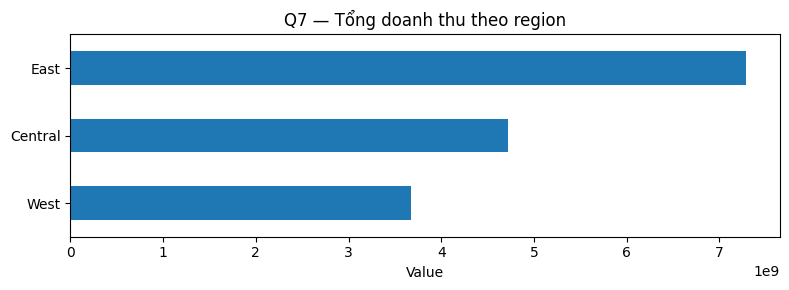

In [49]:
rev_line = order_items.copy()
rev_line['line_revenue'] = (
    rev_line['quantity'] * rev_line['unit_price']
    - rev_line['discount_amount'].fillna(0)
)

order_region = orders[['order_id', 'zip']].merge(
    geography[['zip', 'region']],
    on='zip',
    how='left'
)

line_region = rev_line.merge(order_region[['order_id', 'region']], on='order_id', how='left')
q7_series = line_region.groupby('region')['line_revenue'].sum().sort_values(ascending=False)
q7_answer_value = q7_series.index[0]

print(f'Q7 region cao nhất = {q7_answer_value}')
show_ranked_series(q7_series, 'Q7 — Tổng doanh thu theo region')

## Q8. Payment method phổ biến nhất trong đơn hàng cancelled


Q8 payment method phổ biến nhất = credit_card


,value
payment_method,
credit_card,28452
cod,15468
paypal,7817
apple_pay,5190
bank_transfer,2535


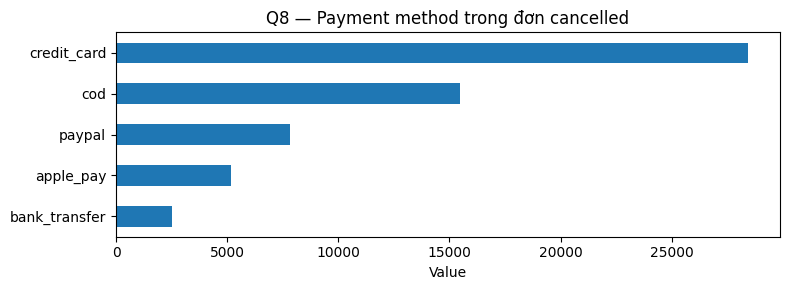

In [50]:
cancelled_orders = orders[orders['order_status'].eq('cancelled')]
q8_series = cancelled_orders['payment_method'].value_counts()
q8_answer_value = q8_series.index[0]

print(f'Q8 payment method phổ biến nhất = {q8_answer_value}')
show_ranked_series(q8_series, 'Q8 — Payment method trong đơn cancelled')

## Q9. Size có tỷ lệ trả hàng cao nhất



Q9 size có tỷ lệ trả hàng cao nhất = S


,value
size,
S,0.0565
L,0.0562
M,0.0557
XL,0.0552


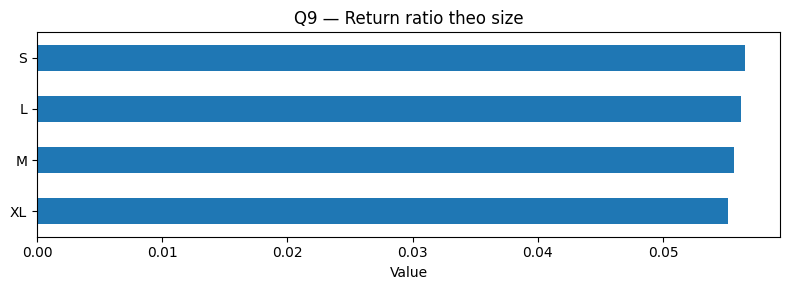

In [51]:
size_items = order_items.merge(products[['product_id', 'size']], on='product_id', how='left')
size_returns = returns.merge(products[['product_id', 'size']], on='product_id', how='left')

denominator = size_items.groupby('size').size()
numerator = size_returns.groupby('size').size()
q9_series = (numerator / denominator).sort_values(ascending=False)
q9_answer_value = q9_series.index[0]

print(f'Q9 size có tỷ lệ trả hàng cao nhất = {q9_answer_value}')
show_ranked_series(q9_series, 'Q9 — Return ratio theo size')

## Q10. Installments có payment value trung bình cao nhất


Q10 installments cao nhất = 6


,value
installments,
6,"24,446.6544"
3,"24,399.6355"
12,"24,245.7727"
1,"24,113.2742"
2,708.4737


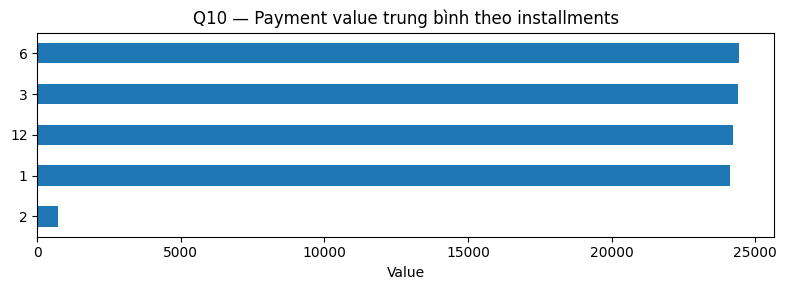

In [52]:
per_order_payment = (
    payments
    .groupby(['order_id', 'installments'], as_index=False)['payment_value']
    .sum()
)
q10_series = per_order_payment.groupby('installments')['payment_value'].mean().sort_values(ascending=False)
q10_answer_value = q10_series.index[0]

print(f'Q10 installments cao nhất = {q10_answer_value}')
show_ranked_series(q10_series, 'Q10 — Payment value trung bình theo installments')